# 01 - Correccion de senales sismicas

Caso USGS/PRISM: lectura SMC sin corregir, correccion por dos caminos y comparacion contra aceleracion, velocidad y desplazamiento corregidos por USGS.

Este notebook deja disponibles dos flujos:

1. **Recomendacion automatica**: el paquete estima ventanas, filtros y correcciones candidatas, las puntua y selecciona una configuracion.
2. **Parametros de usuario**: el usuario escribe explicitamente la configuracion de correccion. En este ejemplo se usa filtro Butterworth pasa-banda entre 0.02 y 25 Hz.


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from signalprocessor.io import read_motion
from signalprocessor.metrics import (
    compute_ground_motion_parameters,
    compute_ground_motion_parameters_from_series,
    cumulative_arias,
    ground_motion_parameters_to_dict,
    integrate_motion,
)
from signalprocessor.processing import CorrectionConfig, correct_record
from signalprocessor.recommendation import recommend_correction_method
from signalprocessor.spectra import response_spectrum


## Datos de entrada

Se usa un componente SMC sin corregir y los productos USGS corregidos correspondientes: aceleracion (`_a`), velocidad (`_v`) y desplazamiento (`_d`).

In [2]:
component = 'CCSP.HNN..'
raw_path = ROOT / f'examples/data/benchmark/uncorrected_motion/{component}_u.smc'
ref_acc_path = ROOT / f'examples/data/benchmark/corrected_motion/{component}_a.smc'
ref_vel_path = ROOT / f'examples/data/benchmark/corrected_motion/{component}_v.smc'
ref_disp_path = ROOT / f'examples/data/benchmark/corrected_motion/{component}_d.smc'

raw = read_motion(raw_path)
reference_acc = read_motion(ref_acc_path, units='cm/s^2')
reference_vel = read_motion(ref_vel_path, units='cm/s^2')  # canal numerico en cm/s
reference_disp = read_motion(ref_disp_path, units='cm/s^2')  # canal numerico en cm

pd.DataFrame([{
    'component': component,
    'npts': raw.npts,
    'dt_s': raw.dt,
    'duration_s': raw.duration,
    'units': raw.units,
}])


,component,npts,dt_s,duration_s,units
0,CCSP.HNN..,20200,0.01,201.99,cm/s^2


## Camino 1: recomendacion automatica de parametros

El flujo automatizado sigue el marco teorico de correccion de senales:

1. Detecta ventanas por intensidad de Arias: pre-evento, fase fuerte y post-evento.
2. Evalua deriva cruda integrando aceleracion a velocidad y desplazamiento.
3. Detecta posibles spikes con una derivada robusta.
4. Estima cortes de filtro con relacion senal/ruido en Fourier cuando hay pre-evento suficiente.
5. Construye alternativas de baseline de bajo orden, sensibilidad de high-pass y controles de deriva de largo periodo usando solo las familias de filtro indicadas por el usuario.
6. Estima los coeficientes del polinomio de linea base de cada candidato y los guarda para trazabilidad/reproduccion.
7. Puntua cada alternativa por velocidad final, desplazamiento final normalizado por PGV, PGD/PGV, ondulacion post-evento, cambio espectral, PGA, Arias, CAV y complejidad.

`FILTER_TYPES_RECOMMENDATION` controla las familias evaluadas. Use `None`, `'all'` o `'todas'` para evaluar todas las disponibles; use una cadena o lista para limitar el barrido, por ejemplo `'bessel'`, `'cheby2'` o `['butterworth', 'bessel']`.


In [3]:
# Familias de filtro que entran al barrido automatico.
# Opciones canonicas: 'butterworth', 'cheby1', 'cheby2', 'ellip', 'bessel'.
# Tambien acepta alias: 'all'/'todas' para todas, 'chebyshev', 'chevyshev', 'elliptic', etc.
FILTER_TYPES_RECOMMENDATION = 'butterworth'
# Ejemplos:
# FILTER_TYPES_RECOMMENDATION = 'bessel'
# FILTER_TYPES_RECOMMENDATION = ['butterworth', 'bessel']

recommendation = recommend_correction_method(
    raw,
    t_min=0.05,
    t_max=3.0,
    snr_threshold=3.0,
    filter_types=FILTER_TYPES_RECOMMENDATION,
)
params = recommendation.parameter_suggestion
recommended = recommendation.best
result = recommended.result
project_acc = result.record.as_units('cm/s^2')

print('\n'.join(recommendation.decision_notes))
print('Notas de parametros:')
for note in params.notes:
    print(f'- {note}')

parameter_table = pd.DataFrame([params.to_row()]).T.rename(columns={0: 'valor_sugerido'})
parameter_table


Metodo recomendado: baseline_0_hp_0.1_postpoly_1_vf_df.
Familias de filtro consideradas: butterworth.
Los parametros se estimaron con ventanas Arias, SNR Fourier, drift terminal y sensibilidad de baseline/filtro.
Coeficientes recomendados de baseline pre-filtro [m/s^2, tau 0-1]: 0.009941875409.
Coeficientes recomendados de baseline post-filtro [m/s^2, tau 0-1]: 1.086244146e-05, -1.667968401e-05.
La seleccion penaliza desplazamiento/velocidad de largo periodo no fisicos, deriva y tendencia post-evento sin distorsionar excesivamente PGA, Arias, CAV ni espectro.
Si el registro puede contener desplazamiento permanente fisico, revise manualmente candidatos con desplazamiento final impuesto.
Notas de parametros:
- Ventana pre-evento estimada: 10.873645819988228 s.
- Deriva cruda: velocidad final/PGV=1, desplazamiento final/PGD=1; severidad alta.
- Despiking activado; candidatos detectados=552.
- Familias de filtro evaluadas: butterworth.
- High-pass estimado por SNR: 0.0244 Hz.
- Low-pass es

,valor_sugerido
pre_event_seconds,10.873646
baseline_orders,"1, 2, 0"
highpass_hz_candidates,"None, 0.02, 0.0244, 0.0391, 0.05, 0.08, 0.1"
lowpass_hz,25.0
taper_fraction,0.01
filter_order,4
filter_types,butterworth
despike,True
spike_sigma,8.0
constrain_final_velocity,True


In [4]:
def _coefficients_to_text(coefficients):
    if coefficients is None:
        return ''
    arr = np.asarray(coefficients, dtype=float).ravel()
    if arr.size == 0:
        return ''
    return ', '.join(f'{value:.10g}' for value in arr)

recommended_baseline_table = pd.DataFrame([
    {
        'etapa': 'pre-filtro',
        'fuente': result.diagnostics.get('pre_filter_baseline_source', ''),
        'orden': result.diagnostics.get('pre_filter_baseline_order', recommended.config.baseline_order),
        'coeficientes_m_s2': _coefficients_to_text(result.diagnostics.get('pre_filter_baseline_coefficients')),
        'convencion': 'c0 + c1*tau + c2*tau^2 + ..., tau en [0, 1]',
    },
    {
        'etapa': 'post-filtro',
        'fuente': result.diagnostics.get('post_filter_baseline_source', ''),
        'orden': result.diagnostics.get('post_filter_baseline_order', recommended.config.post_filter_baseline_order),
        'coeficientes_m_s2': _coefficients_to_text(result.diagnostics.get('post_filter_baseline_coefficients')),
        'convencion': 'c0 + c1*tau + c2*tau^2 + ..., tau en [0, 1]',
    },
]).set_index('etapa')
recommended_baseline_table


,fuente,orden,coeficientes_m_s2,convencion
etapa,,,,
pre-filtro,estimated,0,0.009941875409,"c0 + c1*tau + c2*tau^2 + ..., tau en [0, 1]"
post-filtro,estimated,1,"1.086244146e-05, -1.667968401e-05","c0 + c1*tau + c2*tau^2 + ..., tau en [0, 1]"


## Camino 2: parametros escritos por el usuario

Para que el camino manual reproduzca exactamente la recomendacion automatica, no basta con copiar `highpass_hz`, `lowpass_hz` y `filter_type`. Tambien deben coincidir `pre_event_seconds`, `baseline_order`, `taper_fraction`, `despike`, `spike_sigma`, restricciones finales y la correccion polinomial posterior al filtro.


Los coeficientes del polinomio pueden dejarse en `None` para que el sistema los estime, o pueden entregarse explicitamente en `CUSTOM_BASELINE_COEFFICIENTS` y `CUSTOM_POST_FILTER_BASELINE_COEFFICIENTS`. La convencion es `c0 + c1*tau + c2*tau**2 + ...`, con `tau` normalizado de 0 a 1 y coeficientes en m/s2.


In [5]:
# Configuracion manual editable por el usuario.
# Modo recomendado para verificar equivalencia: copiar todos los campos de recommended.config.
# Cambia MANUAL_MODE a 'custom' para probar parametros escritos manualmente.
MANUAL_MODE = 'custom'  # opciones: 'match_auto' o 'custom'

# Caso manual editable. Este bloque se usa solo si MANUAL_MODE = 'custom'.
# Ejemplo anterior: Butterworth entre 0.02 y 25 Hz.
CUSTOM_REMOVE_MEAN = True
CUSTOM_PRE_EVENT_SECONDS = params.windows.pre_event_seconds
CUSTOM_FILTER_TYPE = 'butterworth'
CUSTOM_HIGHPASS_HZ = 0.02
CUSTOM_LOWPASS_HZ = 25.0
CUSTOM_FILTER_ORDER = 4
CUSTOM_FILTER_RIPPLE_DB = 0.5
CUSTOM_FILTER_ATTENUATION_DB = 40.0
CUSTOM_BESSEL_NORM = 'phase'
CUSTOM_BASELINE_ORDER = 0
CUSTOM_TAPER_FRACTION = 0.01
CUSTOM_DESPIKE = True
CUSTOM_SPIKE_SIGMA = 8.0
CUSTOM_ZERO_PHASE = True
CUSTOM_CONSTRAIN_FINAL_VELOCITY = True
CUSTOM_CONSTRAIN_FINAL_DISPLACEMENT = False

# Coeficientes explicitos opcionales del polinomio de linea base en m/s2.
# Convencion: baseline(tau) = c0 + c1*tau + c2*tau**2 + ..., tau normalizado en [0, 1].
# Use None para que el sistema estime los coeficientes segun baseline_order y restricciones.
CUSTOM_BASELINE_COEFFICIENTS = None
CUSTOM_POST_FILTER_BASELINE_COEFFICIENTS = None

# Para reproducir la recomendacion usando coeficientes explicitos, descomente:
# CUSTOM_BASELINE_COEFFICIENTS = tuple(result.diagnostics['pre_filter_baseline_coefficients'])
# CUSTOM_POST_FILTER_BASELINE_COEFFICIENTS = tuple(result.diagnostics.get('post_filter_baseline_coefficients', ())) or None

CUSTOM_POST_FILTER_BASELINE_ORDER = 1
CUSTOM_POST_FILTER_CONSTRAIN_FINAL_VELOCITY = True
CUSTOM_POST_FILTER_CONSTRAIN_FINAL_DISPLACEMENT = True

if MANUAL_MODE == 'match_auto':
    # Copia exacta de la configuracion ganadora del recomendador.
    # Esto sirve para validar que el camino manual y el automatico son reproducibles.
    USER_REMOVE_MEAN = recommended.config.remove_mean
    USER_PRE_EVENT_SECONDS = recommended.config.pre_event_seconds
    USER_FILTER_TYPE = recommended.config.filter_type
    USER_HIGHPASS_HZ = recommended.config.highpass_hz
    USER_LOWPASS_HZ = recommended.config.lowpass_hz
    USER_FILTER_ORDER = recommended.config.filter_order
    USER_FILTER_RIPPLE_DB = recommended.config.filter_ripple_db
    USER_FILTER_ATTENUATION_DB = recommended.config.filter_attenuation_db
    USER_BESSEL_NORM = recommended.config.bessel_norm
    USER_BASELINE_ORDER = recommended.config.baseline_order
    USER_TAPER_FRACTION = recommended.config.taper_fraction
    USER_DESPIKE = recommended.config.despike
    USER_SPIKE_SIGMA = recommended.config.spike_sigma
    USER_ZERO_PHASE = recommended.config.zero_phase
    USER_CONSTRAIN_FINAL_VELOCITY = recommended.config.constrain_final_velocity
    USER_CONSTRAIN_FINAL_DISPLACEMENT = recommended.config.constrain_final_displacement
    USER_BASELINE_COEFFICIENTS = recommended.config.baseline_coefficients
    USER_POST_FILTER_BASELINE_COEFFICIENTS = recommended.config.post_filter_baseline_coefficients
    USER_POST_FILTER_BASELINE_ORDER = recommended.config.post_filter_baseline_order
    USER_POST_FILTER_CONSTRAIN_FINAL_VELOCITY = recommended.config.post_filter_constrain_final_velocity
    USER_POST_FILTER_CONSTRAIN_FINAL_DISPLACEMENT = recommended.config.post_filter_constrain_final_displacement
    manual_mode_label = 'copia exacta de recomendacion'
elif MANUAL_MODE == 'custom':
    USER_REMOVE_MEAN = CUSTOM_REMOVE_MEAN
    USER_PRE_EVENT_SECONDS = CUSTOM_PRE_EVENT_SECONDS
    USER_FILTER_TYPE = CUSTOM_FILTER_TYPE
    USER_HIGHPASS_HZ = CUSTOM_HIGHPASS_HZ
    USER_LOWPASS_HZ = CUSTOM_LOWPASS_HZ
    USER_FILTER_ORDER = CUSTOM_FILTER_ORDER
    USER_FILTER_RIPPLE_DB = CUSTOM_FILTER_RIPPLE_DB
    USER_FILTER_ATTENUATION_DB = CUSTOM_FILTER_ATTENUATION_DB
    USER_BESSEL_NORM = CUSTOM_BESSEL_NORM
    USER_BASELINE_ORDER = CUSTOM_BASELINE_ORDER
    USER_TAPER_FRACTION = CUSTOM_TAPER_FRACTION
    USER_DESPIKE = CUSTOM_DESPIKE
    USER_SPIKE_SIGMA = CUSTOM_SPIKE_SIGMA
    USER_ZERO_PHASE = CUSTOM_ZERO_PHASE
    USER_CONSTRAIN_FINAL_VELOCITY = CUSTOM_CONSTRAIN_FINAL_VELOCITY
    USER_CONSTRAIN_FINAL_DISPLACEMENT = CUSTOM_CONSTRAIN_FINAL_DISPLACEMENT
    USER_BASELINE_COEFFICIENTS = CUSTOM_BASELINE_COEFFICIENTS
    USER_POST_FILTER_BASELINE_COEFFICIENTS = CUSTOM_POST_FILTER_BASELINE_COEFFICIENTS
    USER_POST_FILTER_BASELINE_ORDER = CUSTOM_POST_FILTER_BASELINE_ORDER
    USER_POST_FILTER_CONSTRAIN_FINAL_VELOCITY = CUSTOM_POST_FILTER_CONSTRAIN_FINAL_VELOCITY
    USER_POST_FILTER_CONSTRAIN_FINAL_DISPLACEMENT = CUSTOM_POST_FILTER_CONSTRAIN_FINAL_DISPLACEMENT
    manual_mode_label = 'parametros escritos por el usuario'
else:
    raise ValueError("MANUAL_MODE debe ser 'match_auto' o 'custom'")

manual_config = CorrectionConfig(
    remove_mean=USER_REMOVE_MEAN,
    pre_event_seconds=USER_PRE_EVENT_SECONDS,
    baseline_order=USER_BASELINE_ORDER,
    constrain_final_velocity=USER_CONSTRAIN_FINAL_VELOCITY,
    constrain_final_displacement=USER_CONSTRAIN_FINAL_DISPLACEMENT,
    baseline_coefficients=USER_BASELINE_COEFFICIENTS,
    despike=USER_DESPIKE,
    spike_sigma=USER_SPIKE_SIGMA,
    taper_fraction=USER_TAPER_FRACTION,
    highpass_hz=USER_HIGHPASS_HZ,
    lowpass_hz=USER_LOWPASS_HZ,
    filter_order=USER_FILTER_ORDER,
    filter_type=USER_FILTER_TYPE,
    filter_ripple_db=USER_FILTER_RIPPLE_DB,
    filter_attenuation_db=USER_FILTER_ATTENUATION_DB,
    bessel_norm=USER_BESSEL_NORM,
    zero_phase=USER_ZERO_PHASE,
    post_filter_baseline_order=USER_POST_FILTER_BASELINE_ORDER,
    post_filter_baseline_coefficients=USER_POST_FILTER_BASELINE_COEFFICIENTS,
    post_filter_constrain_final_velocity=USER_POST_FILTER_CONSTRAIN_FINAL_VELOCITY,
    post_filter_constrain_final_displacement=USER_POST_FILTER_CONSTRAIN_FINAL_DISPLACEMENT,
)
manual_result = correct_record(raw, manual_config)
manual_acc = manual_result.record.as_units('cm/s^2')
manual_vel_cms = manual_result.velocity * 100.0
manual_disp_cm = manual_result.displacement * 100.0
manual_label = f'Usuario ({manual_mode_label}: {USER_FILTER_TYPE}, hp={USER_HIGHPASS_HZ:g} Hz, lp={USER_LOWPASS_HZ:g} Hz)'

config_fields = [
    'remove_mean',
    'pre_event_seconds',
    'filter_type',
    'highpass_hz',
    'lowpass_hz',
    'filter_order',
    'filter_ripple_db',
    'filter_attenuation_db',
    'bessel_norm',
    'baseline_order',
    'taper_fraction',
    'despike',
    'spike_sigma',
    'zero_phase',
    'constrain_final_velocity',
    'constrain_final_displacement',
    'baseline_coefficients',
    'post_filter_baseline_order',
    'post_filter_baseline_coefficients',
    'post_filter_constrain_final_velocity',
    'post_filter_constrain_final_displacement',
]
config_comparison = pd.DataFrame([
    {
        'campo': field,
        'recomendacion_auto': getattr(recommended.config, field),
        'usuario_manual': getattr(manual_config, field),
        'coincide': getattr(recommended.config, field) == getattr(manual_config, field),
    }
    for field in config_fields
]).set_index('campo')
manual_baseline_table = pd.DataFrame([
    {
        'etapa': 'pre-filtro',
        'fuente': manual_result.diagnostics.get('pre_filter_baseline_source', ''),
        'orden': manual_result.diagnostics.get('pre_filter_baseline_order', manual_config.baseline_order),
        'coeficientes_m_s2': _coefficients_to_text(manual_result.diagnostics.get('pre_filter_baseline_coefficients')),
    },
    {
        'etapa': 'post-filtro',
        'fuente': manual_result.diagnostics.get('post_filter_baseline_source', ''),
        'orden': manual_result.diagnostics.get('post_filter_baseline_order', manual_config.post_filter_baseline_order),
        'coeficientes_m_s2': _coefficients_to_text(manual_result.diagnostics.get('post_filter_baseline_coefficients')),
    },
]).set_index('etapa')

display(config_comparison)
display(manual_baseline_table)


,recomendacion_auto,usuario_manual,coincide
campo,,,
remove_mean,True,True,True
pre_event_seconds,10.873646,10.873646,True
filter_type,butterworth,butterworth,True
highpass_hz,0.1,0.02,False
lowpass_hz,25.0,25.0,True
filter_order,4,4,True
filter_ripple_db,0.5,0.5,True
filter_attenuation_db,40.0,40.0,True
bessel_norm,phase,phase,True


,fuente,orden,coeficientes_m_s2
etapa,,,
pre-filtro,estimated,0,0.009941875409
post-filtro,estimated,1,"-0.0002078128159, 0.0003114243742"


In [6]:
n_check = min(project_acc.npts, manual_acc.npts, result.velocity.size, manual_result.velocity.size, result.displacement.size, manual_result.displacement.size)
auto_manual_check = pd.DataFrame([
    {
        'max_abs_acc_diff_cm_s2': float(np.max(np.abs(project_acc.acceleration[:n_check] - manual_acc.acceleration[:n_check]))),
        'max_abs_vel_diff_cm_s': float(np.max(np.abs(result.velocity[:n_check] * 100.0 - manual_result.velocity[:n_check] * 100.0))),
        'max_abs_disp_diff_cm': float(np.max(np.abs(result.displacement[:n_check] * 100.0 - manual_result.displacement[:n_check] * 100.0))),
    }
])
auto_manual_check


,max_abs_acc_diff_cm_s2,max_abs_vel_diff_cm_s,max_abs_disp_diff_cm
0,3.159107,7.198637,53.426627


In [7]:
window_table = pd.DataFrame([params.windows.to_row()]).T.rename(columns={0: 'segundos'})
window_table


,segundos
pre_event_seconds,10.873646
event_start_seconds,8.637483
strong_start_seconds,10.873646
strong_end_seconds,47.213168
post_event_start_seconds,92.853787
d5_95_seconds,71.880641


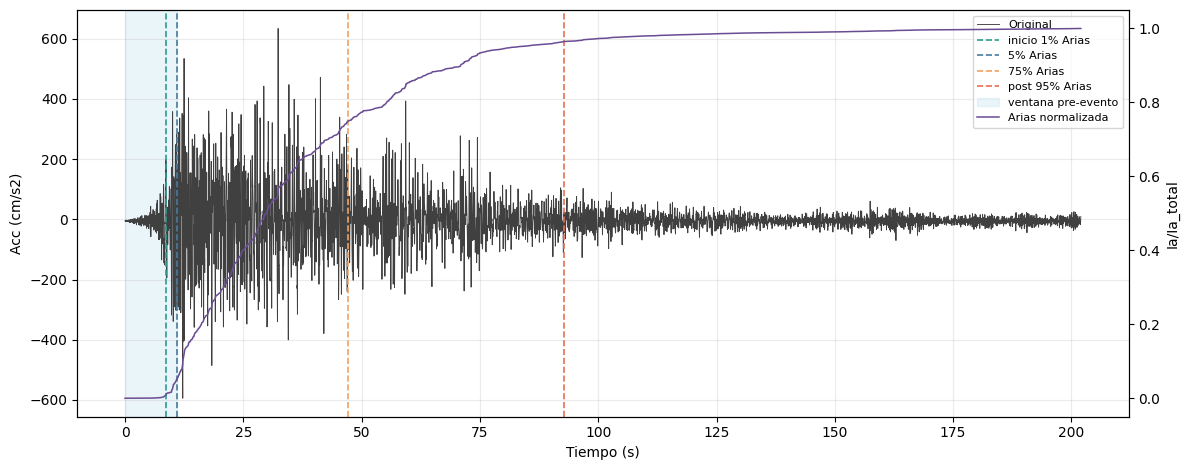

In [8]:
arias = cumulative_arias(raw.acceleration_si(), raw.dt)
fig, ax1 = plt.subplots(figsize=(12, 4.8))
ax1.plot(raw.time, raw.as_units('cm/s^2').acceleration, lw=0.65, color='0.25', label='Original')
ax1.set_xlabel('Tiempo (s)')
ax1.set_ylabel('Acc (cm/s2)')
ax1.grid(alpha=0.25)

for label, x, color in [
    ('inicio 1% Arias', params.windows.event_start_seconds, '#2a9d8f'),
    ('5% Arias', params.windows.strong_start_seconds, '#457b9d'),
    ('75% Arias', params.windows.strong_end_seconds, '#f4a261'),
    ('post 95% Arias', params.windows.post_event_start_seconds, '#e76f51'),
]:
    ax1.axvline(x, color=color, ls='--', lw=1.2, label=label)

if params.windows.pre_event_seconds is not None:
    ax1.axvspan(0.0, params.windows.pre_event_seconds, color='#8ecae6', alpha=0.18, label='ventana pre-evento')

ax2 = ax1.twinx()
ax2.plot(raw.time, arias / arias[-1], color='#6a4c93', lw=1.1, label='Arias normalizada')
ax2.set_ylabel('Ia/Ia_total')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right', fontsize=8)
fig.tight_layout()


## Ranking de alternativas evaluadas

El score menor es mejor. Las razones de velocidad son adimensionales; `final_displacement_pgv_seconds` y `pgd_pgv_seconds` estan en segundos y ayudan a detectar desplazamientos integrados no fisicos de muy largo periodo.


In [9]:
ranking = pd.DataFrame(recommendation.to_rows())
ranking_view = ranking[[
    'method',
    'score',
    'baseline_order',
    'highpass_hz',
    'lowpass_hz',
    'taper_fraction',
    'final_velocity_ratio',
    'final_displacement_ratio',
    'final_displacement_pgv_seconds',
    'pgd_pgv_seconds',
    'post_event_velocity_drift_ratio',
    'post_event_displacement_range_ratio',
    'baseline_coefficients_mps2',
    'post_filter_baseline_coefficients_mps2',
    'spectral_rms_log_change',
    'pga_log_change',
    'arias_log_change',
    'cav_log_change',
]].head(12)
ranking_view


,method,score,baseline_order,highpass_hz,lowpass_hz,taper_fraction,final_velocity_ratio,final_displacement_ratio,final_displacement_pgv_seconds,pgd_pgv_seconds,post_event_velocity_drift_ratio,post_event_displacement_range_ratio,baseline_coefficients_mps2,post_filter_baseline_coefficients_mps2,spectral_rms_log_change,pga_log_change,arias_log_change,cav_log_change
0,baseline_0_hp_0.1_postpoly_1_vf_df,0.755936,0,0.1000,25.0,0.01,5.463609e-15,2.095824e-12,5.963871e-13,0.284560,0.000097,0.456629,0.009941875409,"1.086244146e-05, -1.667968401e-05",0.053063,0.016993,0.025167,0.021280
1,baseline_0_hp_0.0244_postpoly_1_vf_df,0.792609,0,0.0244,25.0,0.01,4.190258e-14,2.417036e-12,2.835675e-12,1.173203,0.012755,0.550432,0.009941875409,"-0.0001687522718, 0.0002548966887",0.053622,0.018321,0.024992,0.021336
2,baseline_0_hp_0.1,0.815187,0,0.1000,25.0,0.01,1.372206e-03,9.804960e-01,2.913099e-01,0.297105,0.000549,0.790318,0.009941875409,,0.053063,0.016994,0.025167,0.021280
3,baseline_0_hp_0.02_postpoly_1_vf_df,0.815369,0,0.0200,25.0,0.01,4.617247e-14,1.988672e-12,2.810858e-12,1.413435,0.008878,0.569746,0.009941875409,"-0.0002078128159, 0.0003114243742",0.053608,0.018303,0.024989,0.021347
4,baseline_1_hp_0.1,0.826109,1,0.1000,25.0,0.01,2.084954e-03,9.911190e-01,4.460802e-01,0.450077,0.000549,0.674915,"0.01867234035, -0.01746092987",,0.053058,0.016994,0.025167,0.021278
5,baseline_1_hp_0.1_postpoly_1_vf_df,0.829641,1,0.1000,25.0,0.01,5.972392e-15,1.885740e-12,5.874916e-13,0.311544,0.001253,0.489415,"0.01867234035, -0.01746092987","-1.675494324e-05, 2.58158846e-05",0.053058,0.016996,0.025167,0.021278
6,baseline_2_hp_0.1_postpoly_1_vf_df,0.852329,2,0.1000,25.0,0.01,2.143610e-15,4.105463e-13,1.185883e-13,0.288855,0.000372,0.449358,"0.009860787323, 0.03540838839, -0.05286931826","1.010706852e-05, -1.30787863e-05",0.053063,0.016993,0.025167,0.021279
7,baseline_2_hp_0.1,0.909445,2,0.1000,25.0,0.01,1.940923e-03,9.831087e-01,3.157910e-01,0.321217,0.000554,0.769985,"0.009860787323, 0.03540838839, -0.05286931826",,0.053063,0.016994,0.025167,0.021279
8,baseline_0_hp_0.05_postpoly_1_vf_df,0.924242,0,0.0500,25.0,0.01,3.636867e-14,3.271733e-12,2.488919e-12,0.760734,0.015964,0.760905,0.009941875409,"-0.0001388499549, 0.0002071589918",0.053501,0.018310,0.025019,0.021278
9,baseline_1_hp_0.08_postpoly_1_vf_df,0.947064,1,0.0800,25.0,0.01,1.494325e-14,2.168517e-12,9.942103e-13,0.458475,0.000038,0.717324,"0.01867234035, -0.01746092987","5.936603584e-05, -8.818415728e-05",0.053149,0.017845,0.025107,0.021259


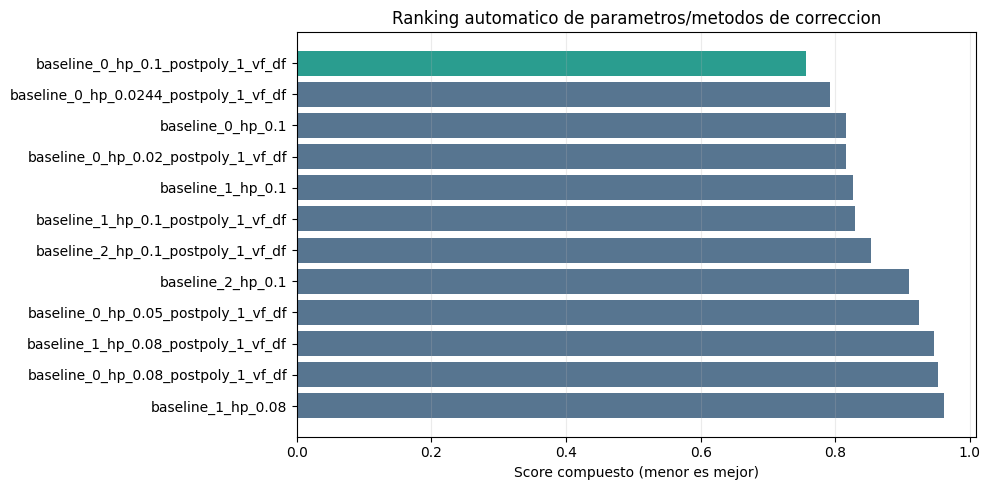

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
top = ranking.head(12).iloc[::-1]
colors = ['#2a9d8f' if method == recommended.name else '#577590' for method in top['method']]
ax.barh(top['method'], top['score'], color=colors)
ax.set_xlabel('Score compuesto (menor es mejor)')
ax.set_title('Ranking automatico de parametros/metodos de correccion')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()


## Comparacion: recomendacion automatica vs parametros de usuario vs USGS

La comparacion incluye los dos caminos disponibles:

- **Proyecto auto**: configuracion seleccionada por el recomendador.
- **Usuario manual**: configuracion escrita explicitamente con Butterworth 0.02-25 Hz.
- **USGS**: canales publicados de aceleracion (`_a`), velocidad (`_v`) y desplazamiento (`_d`).

La tabla de resumen muestra las mismas unidades de los graficos: aceleracion en cm/s2, velocidad en cm/s y desplazamiento en cm.

Nota: los parametros del objeto `GroundMotionParameters` se almacenan internamente en SI. Para USGS se usan los canales publicados de velocidad (`_v`) y desplazamiento (`_d`) en vez de reintegrar solamente el canal de aceleracion (`_a`), porque esos productos ya incorporan su propia correccion de linea base.


In [11]:
raw_vel_mps, raw_disp_m = integrate_motion(raw.acceleration_si(), raw.dt)
project_vel_cms = result.velocity * 100.0
project_disp_cm = result.displacement * 100.0
raw_vel_cms = raw_vel_mps * 100.0
raw_disp_cm = raw_disp_m * 100.0
project_label = f'Proyecto auto ({recommended.name})'

# Metricas USGS desde los tres canales publicados: aceleracion, velocidad y desplazamiento.
# reference_vel.acceleration contiene numericamente cm/s y reference_disp.acceleration contiene cm.
n_ref = min(reference_acc.npts, reference_vel.npts, reference_disp.npts)
usgs_metrics = compute_ground_motion_parameters_from_series(
    reference_acc.time[:n_ref],
    reference_acc.acceleration_si()[:n_ref],
    velocity_si=reference_vel.acceleration[:n_ref] * 0.01,       # cm/s -> m/s
    displacement_si=reference_disp.acceleration[:n_ref] * 0.01, # cm -> m
)

summary = pd.DataFrame([
    ground_motion_parameters_to_dict(
        compute_ground_motion_parameters(raw),
        acceleration_units='cm/s^2',
        velocity_units='cm/s',
        displacement_units='cm',
        cav_units='cm/s',
        suffix_units=True,
    ) | {'stage': 'original'},
    ground_motion_parameters_to_dict(
        result.metrics,
        acceleration_units='cm/s^2',
        velocity_units='cm/s',
        displacement_units='cm',
        cav_units='cm/s',
        suffix_units=True,
    ) | {'stage': project_label},
    ground_motion_parameters_to_dict(
        manual_result.metrics,
        acceleration_units='cm/s^2',
        velocity_units='cm/s',
        displacement_units='cm',
        cav_units='cm/s',
        suffix_units=True,
    ) | {'stage': manual_label},
    ground_motion_parameters_to_dict(
        usgs_metrics,
        acceleration_units='cm/s^2',
        velocity_units='cm/s',
        displacement_units='cm',
        cav_units='cm/s',
        suffix_units=True,
    ) | {'stage': 'USGS canales publicados'},
]).set_index('stage')

summary[[
    'pga_cm_s2',
    'pgv_cm_s',
    'pgd_cm',
    'arias_intensity_m_s',
    'd5_95_s',
    'final_velocity_cm_s',
    'final_displacement_cm',
]]


,pga_cm_s2,pgv_cm_s,pgd_cm,arias_intensity_m_s,d5_95_s,final_velocity_cm_s,final_displacement_cm
stage,,,,,,,
original,634.160000,983.887637,93243.256062,17.408084,71.880641,-9.836970e+02,-9.324326e+04
Proyecto auto (baseline_0_hp_0.1_postpoly_1_vf_df),645.028315,37.161846,10.574766,16.975438,70.599808,-2.030378e-13,-2.216285e-11
"Usuario (parametros escritos por el usuario: butterworth, hp=0.02 Hz, lp=25 Hz)",645.874107,40.610634,57.400497,16.978456,70.601433,1.875093e-12,1.141507e-10
USGS canales publicados,638.320000,38.087000,20.069000,17.329166,69.697811,-2.879100e-02,-5.730300e-01


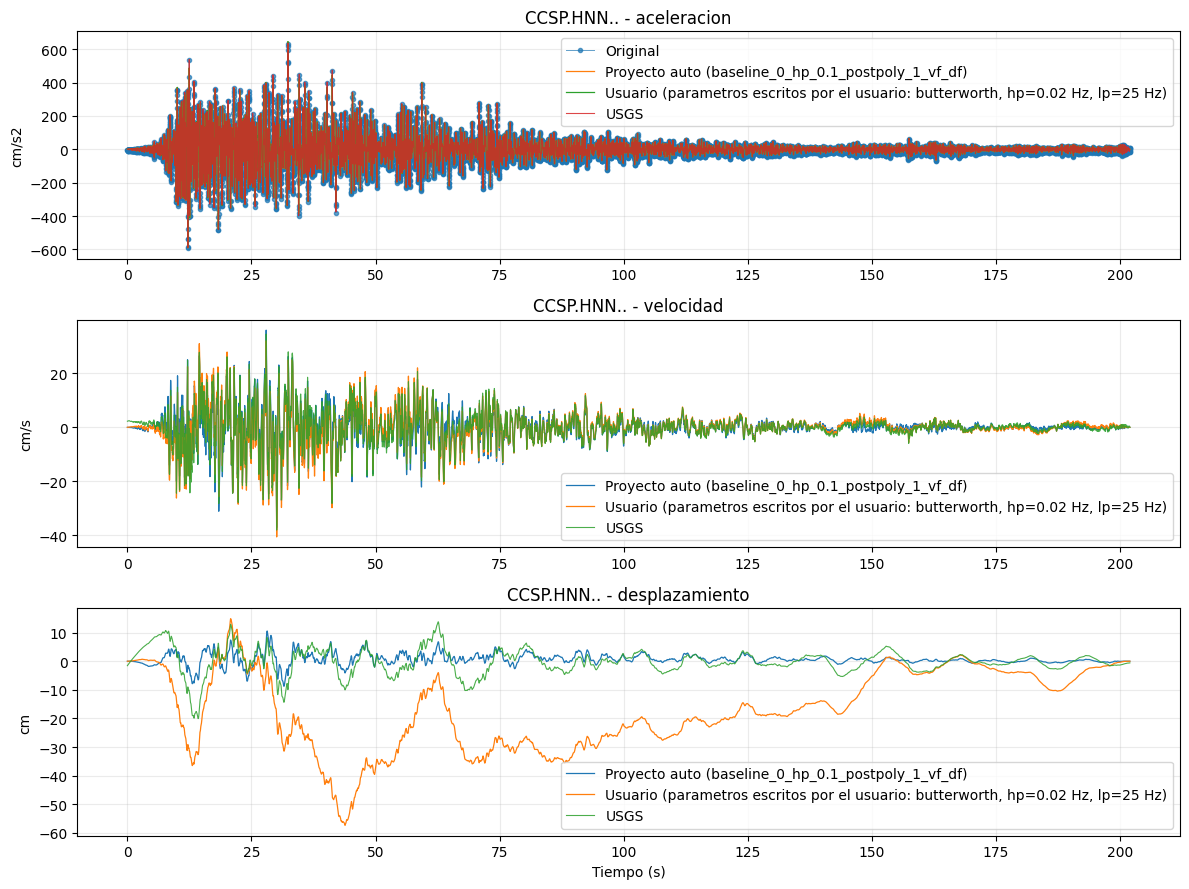

In [12]:
n_acc = min(raw.npts, project_acc.npts, manual_acc.npts, reference_acc.npts)
n_vel = min(raw.npts, result.velocity.size, manual_result.velocity.size, reference_vel.npts)
n_disp = min(raw.npts, result.displacement.size, manual_result.displacement.size, reference_disp.npts)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

axes[0].plot(raw.time[:n_acc], raw.as_units('cm/s^2').acceleration[:n_acc], lw=0.7, alpha=0.7, label='Original', marker='o', markersize=3)
axes[0].plot(project_acc.time[:n_acc], project_acc.acceleration[:n_acc], lw=0.9, label=project_label)
axes[0].plot(manual_acc.time[:n_acc], manual_acc.acceleration[:n_acc], lw=0.9, label=manual_label)
axes[0].plot(reference_acc.time[:n_acc], reference_acc.acceleration[:n_acc], lw=0.8, alpha=0.85, label='USGS')
axes[0].set_title(f'{component} - aceleracion')
axes[0].set_ylabel('cm/s2')

# axes[1].plot(raw.time[:n_vel], raw_vel_cms[:n_vel], lw=0.7, alpha=0.7, label='Original integrada')
axes[1].plot(result.record.time[:n_vel], project_vel_cms[:n_vel], lw=0.9, label=project_label)
axes[1].plot(manual_result.record.time[:n_vel], manual_vel_cms[:n_vel], lw=0.9, label=manual_label)
axes[1].plot(reference_vel.time[:n_vel], reference_vel.acceleration[:n_vel], lw=0.8, alpha=0.85, label='USGS')
axes[1].set_title(f'{component} - velocidad')
axes[1].set_ylabel('cm/s')

# axes[2].plot(raw.time[:n_disp], raw_disp_cm[:n_disp], lw=0.7, alpha=0.7, label='Original integrada')
axes[2].plot(result.record.time[:n_disp], project_disp_cm[:n_disp], lw=0.9, label=project_label)
axes[2].plot(manual_result.record.time[:n_disp], manual_disp_cm[:n_disp], lw=0.9, label=manual_label)
axes[2].plot(reference_disp.time[:n_disp], reference_disp.acceleration[:n_disp], lw=0.8, alpha=0.85, label='USGS')
axes[2].set_title(f'{component} - desplazamiento')
axes[2].set_ylabel('cm')
axes[2].set_xlabel('Tiempo (s)')

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()


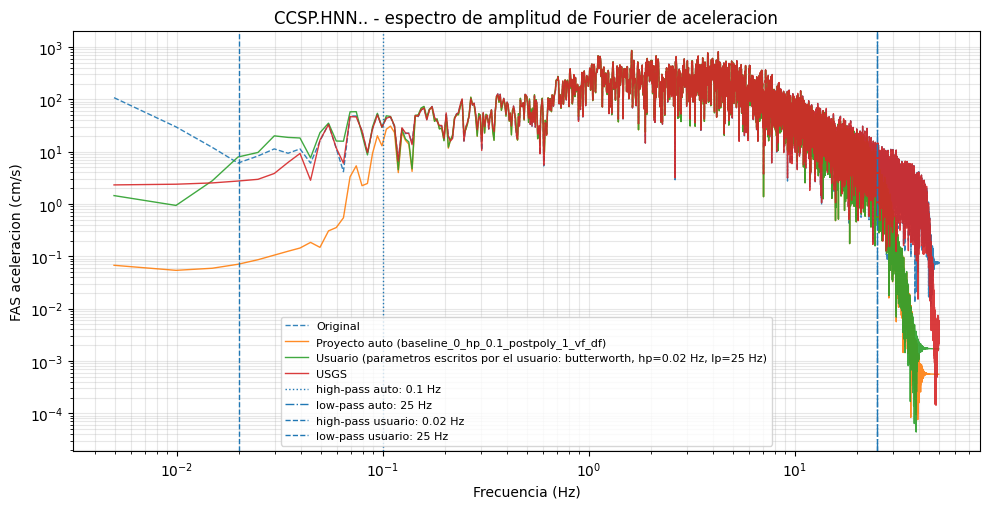

In [13]:
from signalprocessor.spectra import fourier_amplitude_spectrum


def _fas_acc_cm_s(record):
    freqs, amp_m_s = fourier_amplitude_spectrum(record)
    return freqs, amp_m_s * 100.0  # m/s -> cm/s; FAS de aceleracion = (cm/s2) * s


fas_series = [
    (_fas_acc_cm_s(raw), 'Original', '--'),
    (_fas_acc_cm_s(project_acc), project_label, '-'),
    (_fas_acc_cm_s(manual_acc), manual_label, '-'),
    (_fas_acc_cm_s(reference_acc), 'USGS', '-'),
]

fig, ax = plt.subplots(figsize=(10, 5.2))
for (freqs, amp), label, linestyle in fas_series:
    mask = (freqs > 0.0) & np.isfinite(amp) & (amp > 0.0)
    ax.loglog(freqs[mask], amp[mask], linestyle=linestyle, lw=1.0, alpha=0.9, label=label)

cutoff_lines = [
    ('high-pass auto', recommended.config.highpass_hz, ':'),
    ('low-pass auto', recommended.config.lowpass_hz, '-.'),
    ('high-pass usuario', manual_config.highpass_hz, '--'),
    ('low-pass usuario', manual_config.lowpass_hz, '--'),
]
for cutoff_label, cutoff_hz, linestyle in cutoff_lines:
    if cutoff_hz is not None and cutoff_hz > 0.0:
        ax.axvline(cutoff_hz, linestyle=linestyle, lw=1.0, label=f'{cutoff_label}: {cutoff_hz:g} Hz')

ax.set_title(f'{component} - espectro de amplitud de Fourier de aceleracion')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('FAS aceleracion (cm/s)')
ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()


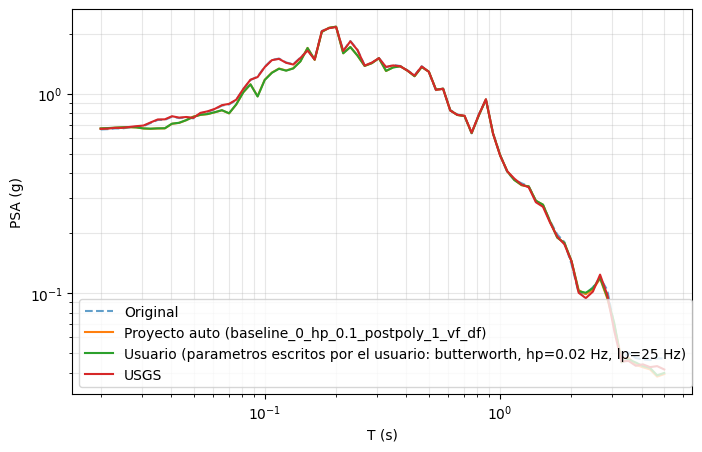

In [14]:
periods = np.geomspace(0.02, 5.0, 80)
spec_raw = response_spectrum(raw, periods)
spec_project = response_spectrum(project_acc, periods)
spec_manual = response_spectrum(manual_acc, periods)
spec_usgs = response_spectrum(reference_acc, periods)

plt.figure(figsize=(8, 5))
plt.loglog(spec_raw.periods, spec_raw.sa, '--', alpha=0.7, label='Original')
plt.loglog(spec_project.periods, spec_project.sa, label=project_label)
plt.loglog(spec_manual.periods, spec_manual.sa, label=manual_label)
plt.loglog(spec_usgs.periods, spec_usgs.sa, label='USGS')
plt.xlabel('T (s)')
plt.ylabel('PSA (g)')
plt.grid(True, which='both', alpha=0.3)
plt.legend();
